In [16]:
# https://chatgpt.com/share/6a924eca-f6b0-83ea-8a08-c0902d8f39c0

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, auc

# ---------------------------------------------------------
# 1. Load Iris dataset
# ---------------------------------------------------------
iris = load_iris()

X = iris.data

# Binary classification:
# 1 = Setosa
# 0 = Not Setosa
y = (iris.target == 0).astype(int)

print("X shape:", X.shape)
print("y:", y)


X shape: (150, 4)
y: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [6]:

# ---------------------------------------------------------
# 2. Train/test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ---------------------------------------------------------
# 3. Train classifier
# ---------------------------------------------------------
model = LogisticRegression(max_iter=1000) # y = sigmoid(a*x1 + b*x2 + c*x3 + d*x4 + e)

model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. Get probability predictions
# ---------------------------------------------------------
y_prob = model.predict_proba(X_test)[:, 1]

print("\nPredicted probabilities:")
print(y_prob)



Predicted probabilities:
[9.75247710e-01 9.11993569e-04 9.87430427e-01 4.28658122e-03
 9.75400858e-01 9.83851924e-01 2.80209449e-03 2.34057405e-03
 1.15513116e-04 9.64715721e-01 6.44251779e-03 8.80740800e-03
 9.76079290e-01 9.85255905e-01 8.87272341e-02 9.78274942e-01
 4.50365211e-04 7.32186759e-05 2.36597856e-01 3.44245640e-02
 2.48221217e-02 1.41298348e-03 1.40372128e-03 9.83019638e-01
 9.82205773e-01 7.44942624e-02 3.69610141e-04 3.13370590e-04
 7.04295829e-04 1.98115464e-04 9.69643432e-01 9.86099654e-01
 5.93225868e-03 2.62387263e-04 9.71546654e-01 7.90345273e-04
 5.90929916e-04 2.93743373e-04 7.33329883e-03 1.49127768e-03
 1.59671560e-04 1.88268981e-04 9.81296447e-01 9.79776985e-01
 1.40372128e-03]


In [ ]:
arr = np.array([1,0, 2, -1])
idx = np.argsort(arr)

array([3, 1, 0, 2])

In [9]:
arr[idx]

NameError: name 'idx' is not defined

In [22]:

# ---------------------------------------------------------
# 5. Calculate TPR and FPR for different thresholds
# ---------------------------------------------------------

thresholds = np.sort(np.unique(y_prob))[::-1]

tpr_values = []
fpr_values = []

precision_values = []
recall_values = []
f1_values = []

for threshold in thresholds:

    # Convert probabilities to class predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix components
    TP = np.sum((y_test == 1) & (y_pred == 1))
    FN = np.sum((y_test == 1) & (y_pred == 0))
    FP = np.sum((y_test == 0) & (y_pred == 1))
    TN = np.sum((y_test == 0) & (y_pred == 0))

    # True Positive Rate
    TPR = TP / (TP + FN)

    # False Positive Rate
    FPR = FP / (FP + TN)
    
    tpr_values.append(TPR)
    fpr_values.append(FPR)

    # Precision
    if TP + FP == 0:
        precision = 1.0
    else:
        precision = TP / (TP + FP)

    # Recall
    if TP + FN == 0:
        recall = 0.0
    else:
        recall = TP / (TP + FN)

    # F1 Score
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    precision_values.append(precision)
    recall_values.append(recall)
    f1_values.append(f1)


# Add (0,0) and (1,1) to make the ROC curve complete
fpr_values = np.array([0] + fpr_values + [1])
tpr_values = np.array([0] + tpr_values + [1])


Best threshold: 0.9647157213431649
Best Precision: 1.0
Best Recall: 1.0
Best F1 Score: 1.0


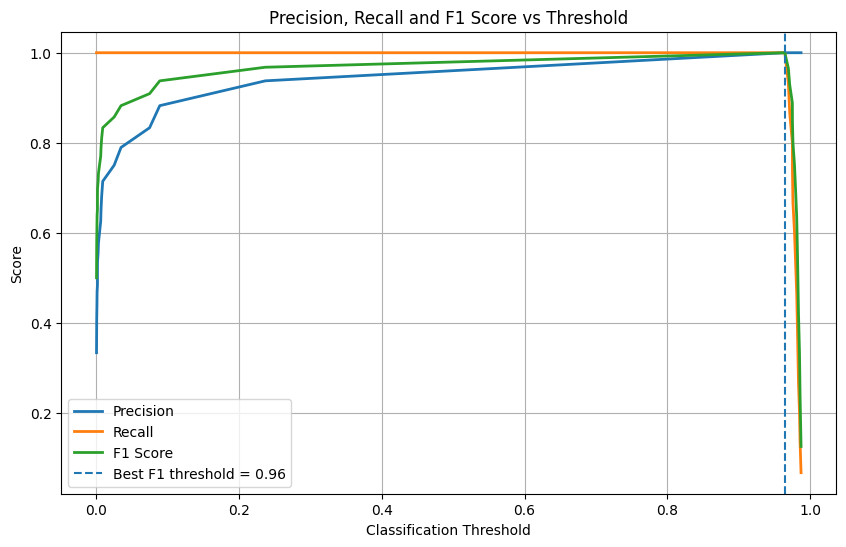

In [23]:

# ---------------------------------------------------------
# 6. Find threshold with maximum F1
# ---------------------------------------------------------

best_index = np.argmax(f1_values)

print("Best threshold:", thresholds[best_index])
print("Best Precision:", precision_values[best_index])
print("Best Recall:", recall_values[best_index])
print("Best F1 Score:", f1_values[best_index])

# ---------------------------------------------------------
# 7. Plot Precision, Recall and F1
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    precision_values,
    label="Precision",
    linewidth=2
)

plt.plot(
    thresholds,
    recall_values,
    label="Recall",
    linewidth=2
)

plt.plot(
    thresholds,
    f1_values,
    label="F1 Score",
    linewidth=2
)

plt.axvline(
    thresholds[best_index],
    linestyle="--",
    label=f"Best F1 threshold = {thresholds[best_index]:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score vs Threshold")

plt.legend()
plt.grid(True)
plt.show()

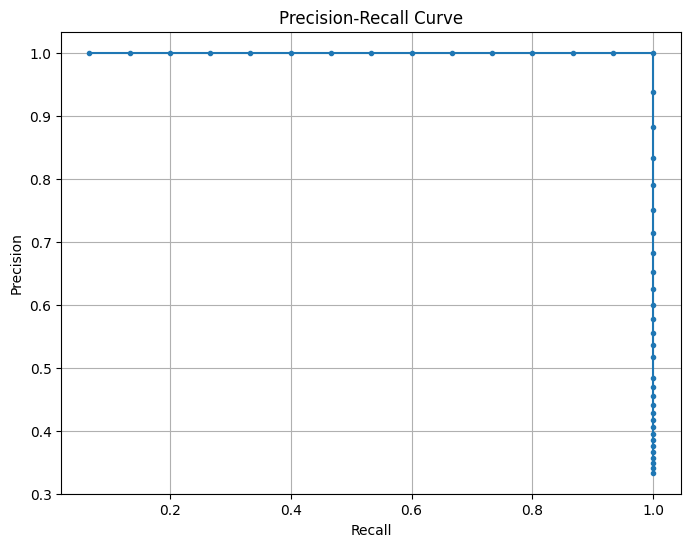

In [24]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    marker="o",
    markersize=3
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid(True)
plt.show()


Manual AUC: 0.991111111111111
sklearn AUC: 1.0


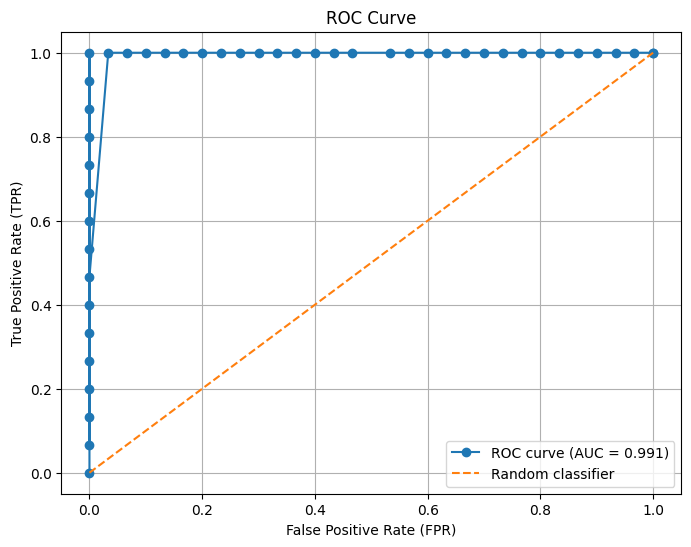

In [13]:

# ---------------------------------------------------------
# 6. Calculate AUC manually using trapezoidal rule
# ---------------------------------------------------------

# FPR must be sorted for integration
order = np.argsort(fpr_values)

fpr_sorted = fpr_values[order]
tpr_sorted = tpr_values[order]

manual_auc = np.trapezoid(tpr_sorted, fpr_sorted)

print("\nManual AUC:", manual_auc)

# ---------------------------------------------------------
# 7. Calculate AUC using sklearn
# ---------------------------------------------------------

sklearn_auc = roc_auc_score(y_test, y_prob)

print("sklearn AUC:", sklearn_auc)

# ---------------------------------------------------------
# 8. Plot ROC curve
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_sorted,
    tpr_sorted,
    marker="o",
    label=f"ROC curve (AUC = {manual_auc:.3f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

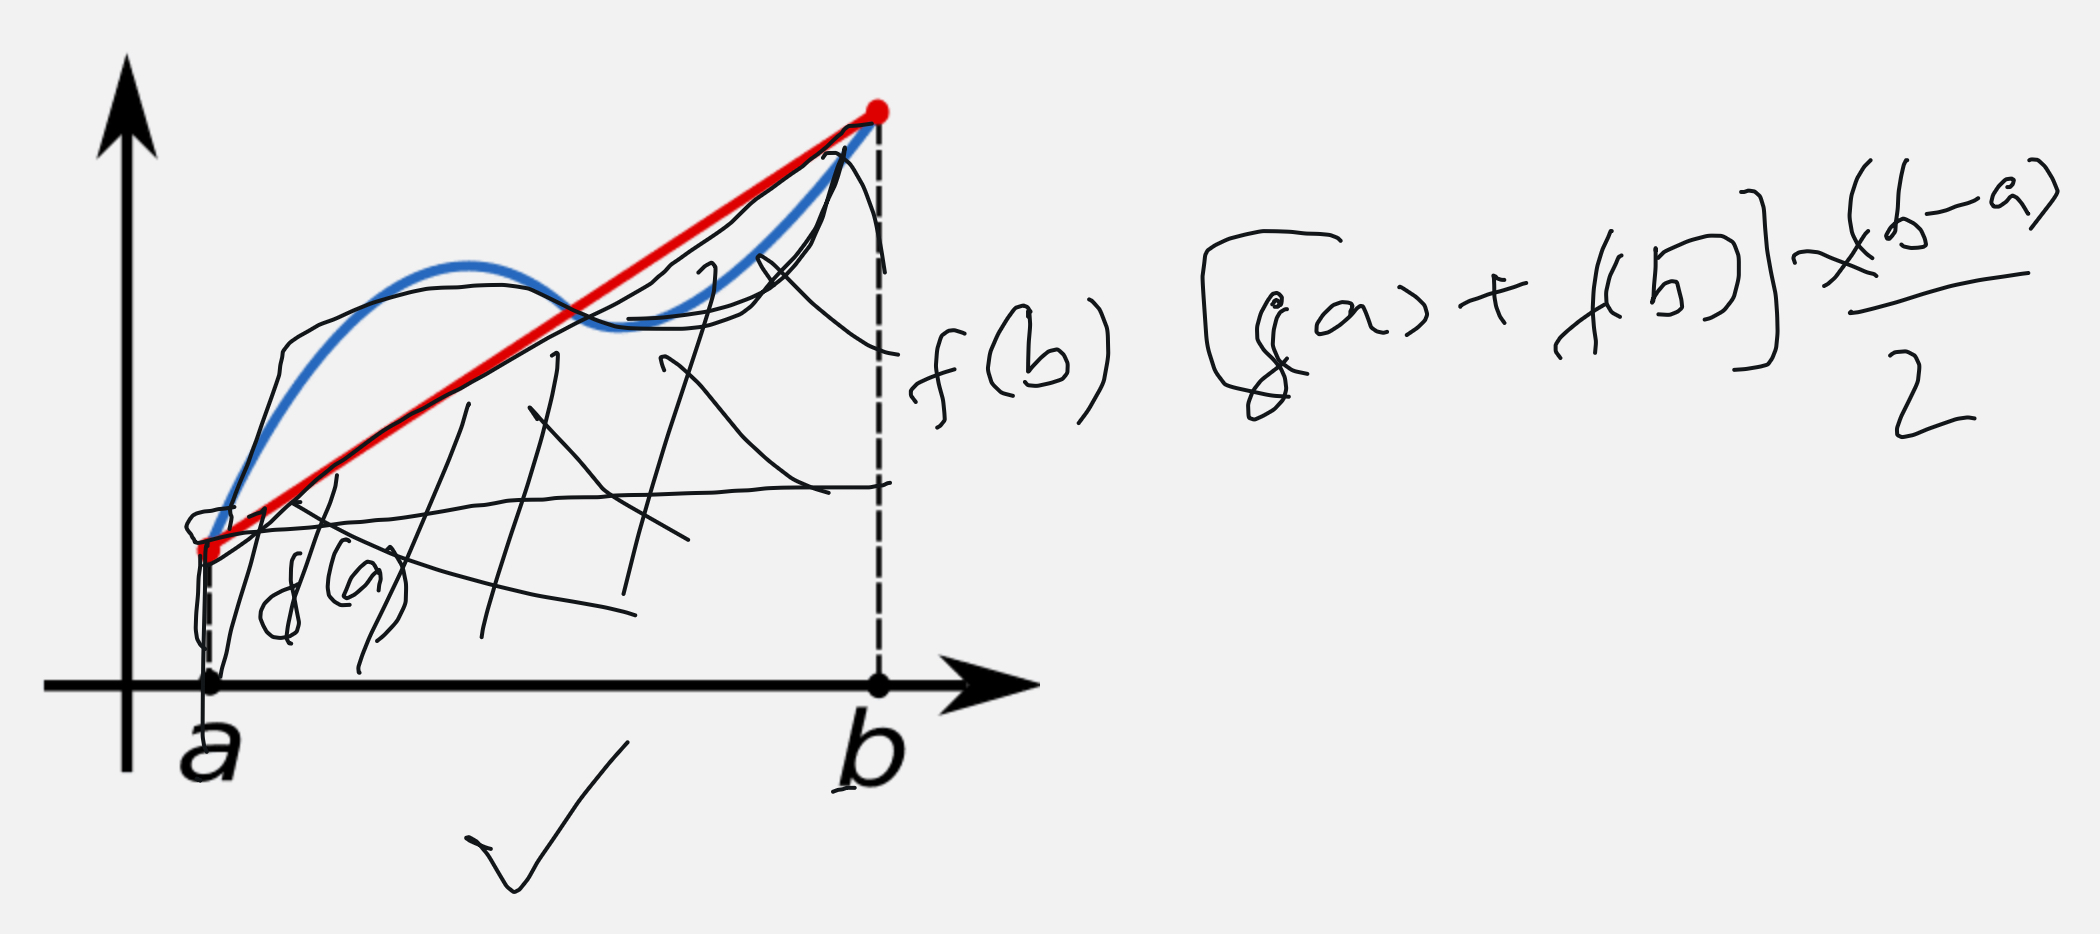

## More questions

1. Pick a thresold that maximizes the recall

2. Pick a thresold that maximizes the precision

3. Pick a thresold that maximizes the F1 Score

In [25]:

# ---------------------------------------------------------
# Best Recall
# ---------------------------------------------------------

best_recall_index = np.argmax(recall_values)

print("Best Recall")
print("----------------")
print("Threshold:", thresholds[best_recall_index])
print("Recall:", recall_values[best_recall_index])
print("Precision:", precision_values[best_recall_index])


# ---------------------------------------------------------
# Best Precision
# ---------------------------------------------------------

best_precision_index = np.argmax(precision_values)

print("\nBest Precision")
print("----------------")
print("Threshold:", thresholds[best_precision_index])
print("Precision:", precision_values[best_precision_index])
print("Recall:", recall_values[best_precision_index])

Best Recall
----------------
Threshold: 0.9647157213431649
Recall: 1.0
Precision: 1.0

Best Precision
----------------
Threshold: 0.987430427018953
Precision: 1.0
Recall: 0.06666666666666667


# SVM

https://chatgpt.com/share/6a925bd5-fc74-83e9-b28e-88db65e368ad


In [26]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [29]:
iris = datasets.load_iris()

X = iris.data
y = iris.target

print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
X shape: (150, 4)
y shape: (150,)
Training samples: 120
Testing samples: 30


In [30]:
svm = SVC(
    kernel="linear",
    C=1.0
)

svm.fit(X_train_scaled, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [32]:
y_pred = svm.predict(X_test_scaled)

print("Predictions:", y_pred)
print("Actual:", y_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)



Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Actual: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Accuracy: 1.0


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


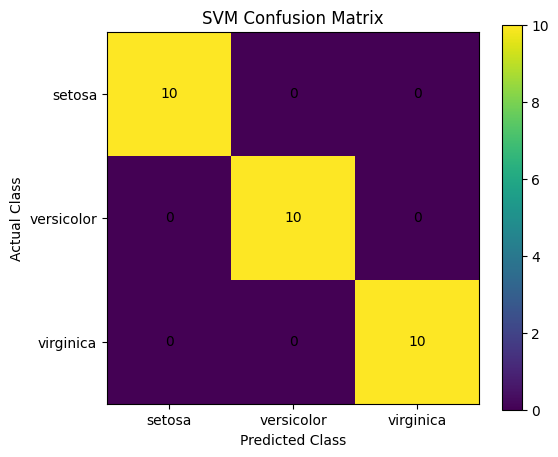

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [33]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(range(3), iris.target_names)
plt.yticks(range(3), iris.target_names)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.show()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


In [34]:
X_2d = iris.data[:, [2, 3]]
y_2d = iris.target

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

scaler_2d = StandardScaler()

X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

svm_2d = SVC(
    kernel="linear",
    C=1.0
)

svm_2d.fit(X_train_2d_scaled, y_train_2d)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


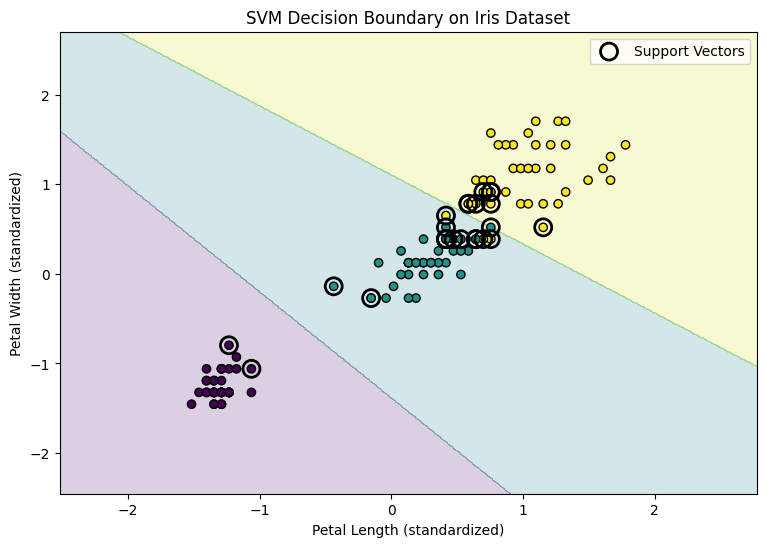

In [36]:
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)
plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2
)

plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_2d,
    edgecolors="k"
)

# Highlight support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=150,
    facecolors="none",
    edgecolors="k",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("Petal Length (standardized)")
plt.ylabel("Petal Width (standardized)")
plt.title("SVM Decision Boundary on Iris Dataset")

plt.legend()
plt.show()




In [ ]:
print("Number of support vectors:",
      len(svm_2d.support_vectors_))

print("\nSupport vectors per class:")
print(svm_2d.n_support_)

print("\nSupport vector indices:")
print(svm_2d.support_)


In [ ]:

```

Plot the decision regions:

```python
```

The highlighted points are the **support vectors**.

---

# 11. Examine the support vectors

One of the most important ideas behind SVM is that the decision boundary is determined primarily by the support vectors.

```python
```

For example, if the output is:

```text
Support vectors per class:
[2 7 6]
```

it means that the model is using:

* 2 support vectors from class 0
* 7 support vectors from class 1
* 6 support vectors from class 2

to determine the separating boundaries.

---

# 12. Experiment with different kernels

SVM becomes particularly powerful when we use nonlinear kernels.

We can compare:

```python
kernels = ["linear", "poly", "rbf", "sigmoid"]

for kernel in kernels:

    model = SVC(
        kernel=kernel,
        C=1.0
    )

    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, prediction)

    print(f"{kernel:8s} : {accuracy:.4f}")
```

Typical kernels are:

| Kernel    | Idea                                 |
| --------- | ------------------------------------ |
| `linear`  | Linear decision boundary             |
| `poly`    | Polynomial decision boundary         |
| `rbf`     | Nonlinear boundary based on distance |
| `sigmoid` | Sigmoid-based kernel                 |

The **RBF kernel** is particularly popular for nonlinear classification.

---

# 13. Experiment with C

The parameter \(C\) controls how strongly the SVM penalizes classification errors.

```python
for C in [0.01, 0.1, 1, 10, 100]:

    model = SVC(
        kernel="linear",
        C=C
    )

    model.fit(X_train_scaled, y_train)

    accuracy = model.score(X_test_scaled, y_test)

    print(f"C = {C:6}  Accuracy = {accuracy:.4f}")
```

Conceptually:

$$
\boxed{\text{Small }C \rightarrow \text{wider margin, more tolerance for errors}}
$$

$$
\boxed{\text{Large }C \rightarrow \text{narrower margin, fewer training errors}}
$$

---

# 14. Experiment with RBF kernel and gamma

For the RBF kernel:

```python
for gamma in ["scale", 0.01, 0.1, 1, 10]:

    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma=gamma
    )

    model.fit(X_train_scaled, y_train)

    accuracy = model.score(X_test_scaled, y_test)

    print(f"gamma = {gamma:>5}  Accuracy = {accuracy:.4f}")
```

The RBF kernel is:

$$
K(x_i,x_j)
=
\exp(-\gamma ||x_i-x_j||^2)
$$

A larger \(\gamma\) makes the model more sensitive to individual training examples and can produce a more complex decision boundary.

---

# 15. Complete compact implementation

The entire basic SVM workflow can be reduced to:

```python
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load data
iris = load_iris()

X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM
model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
```

### Key idea

The central idea of SVM is:

$$
\boxed{
\text{Find a decision boundary that maximizes the margin between classes}
}
$$

The observations closest to that boundary are the **support vectors**, and they play the key role in determining the SVM decision boundary.
